# Neural Collaborative Filtering — He et al. 2017 (NeuMF)

Re-implementation of *Neural Collaborative Filtering* (He, Liao, Zhang, Nie, Hu, Chua — **WWW 2017**), the **NeuMF** model: a two-branch network that fuses **GMF** (Generalized Matrix Factorization — element-wise product of user/item embeddings) and an **MLP** branch (concatenated embeddings passed through stacked dense layers), then combines them through a final fusion layer.


## Architecture (Equation 11 of He et al. 2017)

$$
\hat{y}_{ui} = \sigma\Big(h^{T}\big[\,\underbrace{p^{G}_u \odot q^{G}_i}_{\text{GMF}}\;\big\Vert\; \underbrace{a_L(W_L (\cdots a_1(W_1 [p^{M}_u, q^{M}_i] + b_1) \cdots ) + b_L)}_{\text{MLP}}\,\big]\Big)
$$

GMF and MLP have **separate** user and item embeddings — the GMF embeddings (`p^G`, `q^G`) live in a different space from the MLP embeddings (`p^M`, `q^M`). They're concatenated before the final sigmoid.

## Adaptation to explicit ratings

He et al. 2017 use implicit feedback (binary). We have explicit 0.5–5.0 ratings. We follow the standard adaptation:
1. Normalize target rating to `[0, 1]` via `(r - 0.5) / 4.5`.
2. Train with MSE loss.
3. At inference, scale the sigmoid output back: `pred = sigmoid_out * 4.5 + 0.5`.

## Inputs / outputs

- Reads `splits/{train,val,test}.csv` from `recsys_artifacts/` on Google Drive.
- Writes `predictions/neural_cf.csv` (test-set predictions, used by the hybrid GBRT notebook).


## Setup

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# TensorFlow is preinstalled on Colab; uncomment to pin to a specific version.
# !pip install -q tensorflow==2.15.0
import sys
print('Python:', sys.version.split()[0])

Python: 3.12.13


In [3]:
import os, random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

ARTIFACT_DIR    = Path('/content/gdrive/MyDrive/recsys_artifacts')
SPLITS_DIR      = ARTIFACT_DIR / 'splits'
PREDICTIONS_DIR = ARTIFACT_DIR / 'predictions'
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(ARTIFACT_DIR))
from recsys_metrics import build_candidate_lists, evaluate_model

## Load splits

In [4]:
train = pd.read_csv(SPLITS_DIR / 'train.csv')
val   = pd.read_csv(SPLITS_DIR / 'val.csv')
test  = pd.read_csv(SPLITS_DIR / 'test.csv')
print(f'train: {len(train):,}  val: {len(val):,}  test: {len(test):,}')

train: 99,616  val: 610  test: 610


In [5]:
# Build contiguous integer encodings for users and movies.
all_users  = sorted(set(train['userId'])  | set(val['userId'])  | set(test['userId']))
all_movies = sorted(set(train['movieId']) | set(val['movieId']) | set(test['movieId']))

user2idx  = {u: i for i, u in enumerate(all_users)}
movie2idx = {m: i for i, m in enumerate(all_movies)}
n_users   = len(all_users)
n_movies  = len(all_movies)
print(f'n_users  = {n_users}')
print(f'n_movies = {n_movies}')

n_users  = 610
n_movies = 9724


In [6]:
RATING_MIN, RATING_MAX = 0.5, 5.0
RATING_RANGE = RATING_MAX - RATING_MIN

def to_arrays(df):
    u = df['userId'].map(user2idx).to_numpy(dtype=np.int32)
    m = df['movieId'].map(movie2idx).to_numpy(dtype=np.int32)
    r = ((df['rating'].to_numpy(dtype=np.float32) - RATING_MIN) / RATING_RANGE)
    return u, m, r

u_tr, m_tr, r_tr = to_arrays(train)
u_va, m_va, r_va = to_arrays(val)
u_te, m_te, r_te = to_arrays(test)

## NeuMF model

Two branches with separate embedding tables:

**GMF branch.** User embedding `P^G` of dim `mf_dim`, item embedding `Q^G` of dim `mf_dim`. Output = `P^G ⊙ Q^G` (element-wise product, dim `mf_dim`).

**MLP branch.** User embedding `P^M` of dim `mlp_layers[0]/2`, item embedding `Q^M` of dim `mlp_layers[0]/2`. Concatenated to dim `mlp_layers[0]`, then passed through `len(mlp_layers) - 1` Dense+ReLU layers with the given output sizes. He et al. recommend a pyramidal structure (e.g., `[64, 32, 16, 8]`).

**Fusion.** Concatenate GMF output (dim `mf_dim`) with the final MLP layer (dim `mlp_layers[-1]`). One Dense layer with sigmoid → predicted rating in [0, 1].

In [7]:
def build_neumf(n_users, n_movies, mf_dim=16, mlp_layers=(64, 32, 16, 8), dropout=0.0, reg=1e-6):
    user_input  = keras.Input(shape=(), dtype='int32', name='user')
    movie_input = keras.Input(shape=(), dtype='int32', name='movie')

    # --- GMF branch (separate embeddings) ---
    mf_user_emb = layers.Embedding(
        n_users,  mf_dim,
        embeddings_initializer='he_normal',
        embeddings_regularizer=keras.regularizers.l2(reg),
        name='mf_user_emb')(user_input)
    mf_item_emb = layers.Embedding(
        n_movies, mf_dim,
        embeddings_initializer='he_normal',
        embeddings_regularizer=keras.regularizers.l2(reg),
        name='mf_item_emb')(movie_input)
    gmf_out = layers.Multiply(name='gmf_out')([mf_user_emb, mf_item_emb])

    # --- MLP branch (separate embeddings, total dim = mlp_layers[0]) ---
    mlp_emb_dim = mlp_layers[0] // 2
    mlp_user_emb = layers.Embedding(
        n_users, mlp_emb_dim,
        embeddings_initializer='he_normal',
        embeddings_regularizer=keras.regularizers.l2(reg),
        name='mlp_user_emb')(user_input)
    mlp_item_emb = layers.Embedding(
        n_movies, mlp_emb_dim,
        embeddings_initializer='he_normal',
        embeddings_regularizer=keras.regularizers.l2(reg),
        name='mlp_item_emb')(movie_input)
    mlp_in = layers.Concatenate(name='mlp_concat')([mlp_user_emb, mlp_item_emb])
    x = mlp_in
    for i, units in enumerate(mlp_layers[1:], start=1):
        x = layers.Dense(units, activation='relu', name=f'mlp_dense_{i}',
                         kernel_regularizer=keras.regularizers.l2(reg))(x)
        if dropout > 0:
            x = layers.Dropout(dropout, name=f'mlp_drop_{i}')(x)
    mlp_out = x

    # --- Fusion ---
    fused = layers.Concatenate(name='neumf_concat')([gmf_out, mlp_out])
    pred = layers.Dense(1, activation='sigmoid', name='neumf_out')(fused)

    return keras.Model([user_input, movie_input], pred, name='NeuMF')

model = build_neumf(n_users, n_movies, mf_dim=16, mlp_layers=(64, 32, 16, 8), dropout=0.1, reg=1e-6)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[keras.metrics.RootMeanSquaredError(name='rmse'),
             keras.metrics.MeanAbsoluteError(name='mae')],
)
model.summary()

Model: "NeuMF"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie (InputLayer)  │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_user_emb        │ (None, 32)        │     19,520 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_item_emb        │ (None, 32)        │    311,168 │ movie[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_concat          │ (None, 64)        │          0 │ mlp_user_emb[0][… │
│ (Concatenate)       │                   │            │ mlp_item_emb[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_1 (Dense) │ (None, 32)        │      2,080 │ mlp_concat[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_drop_1          │ (None, 32)        │          0 │ mlp_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_2 (Dense) │ (None, 16)        │        528 │ mlp_drop_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_drop_2          │ (None, 16)        │          0 │ mlp_dense_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mf_user_emb         │ (None, 16)        │      9,760 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mf_item_emb         │ (None, 16)        │    155,584 │ movie[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_3 (Dense) │ (None, 8)         │        136 │ mlp_drop_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmf_out (Multiply)  │ (None, 16)        │          0 │ mf_user_emb[0][0… │
│                     │                   │            │ mf_item_emb[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_drop_3          │ (None, 8)         │          0 │ mlp_dense_3[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neumf_concat        │ (None, 24)        │          0 │ gmf_out[0][0],    │
│ (Concatenate)       │                   │            │ mlp_drop_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neumf_out (Dense)   │ (None, 1)         │         25 │ neumf_concat[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 498,801 (1.90 MB)

 Trainable params: 498,801 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

## Train

Early stopping on validation RMSE; learning-rate reduction on plateau. Best weights are restored at the end. With `ml-latest-small` this typically converges in 10-15 epochs.

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_rmse', mode='min', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_rmse', mode='min', factor=0.5, patience=2, min_lr=1e-5),
]

history = model.fit(
    x=[u_tr, m_tr], y=r_tr,
    validation_data=([u_va, m_va], r_va),
    batch_size=256, epochs=30, verbose=2,
    callbacks=callbacks,
)

Epoch 1/30
390/390 - 13s - 33ms/step - loss: 0.0493 - mae: 0.1744 - rmse: 0.2215 - val_loss: 0.0412 - val_mae: 0.1588 - val_rmse: 0.2022 - learning_rate: 0.0010
Epoch 2/30
390/390 - 1s - 3ms/step - loss: 0.0368 - mae: 0.1473 - rmse: 0.1908 - val_loss: 0.0403 - val_mae: 0.1544 - val_rmse: 0.1996 - learning_rate: 0.0010
Epoch 3/30
390/390 - 1s - 3ms/step - loss: 0.0335 - mae: 0.1391 - rmse: 0.1815 - val_loss: 0.0414 - val_mae: 0.1547 - val_rmse: 0.2015 - learning_rate: 0.0010
Epoch 4/30
390/390 - 1s - 3ms/step - loss: 0.0289 - mae: 0.1274 - rmse: 0.1671 - val_loss: 0.0420 - val_mae: 0.1541 - val_rmse: 0.2021 - learning_rate: 0.0010
Epoch 5/30
390/390 - 1s - 3ms/step - loss: 0.0240 - mae: 0.1142 - rmse: 0.1511 - val_loss: 0.0426 - val_mae: 0.1541 - val_rmse: 0.2035 - learning_rate: 5.0000e-04
Epoch 6/30
390/390 - 2s - 4ms/step - loss: 0.0219 - mae: 0.1074 - rmse: 0.1435 - val_loss: 0.0430 - val_mae: 0.1540 - val_rmse: 0.2042 - learning_rate: 5.0000e-04
Epoch 7/30
390/390 - 2s - 5ms/step -

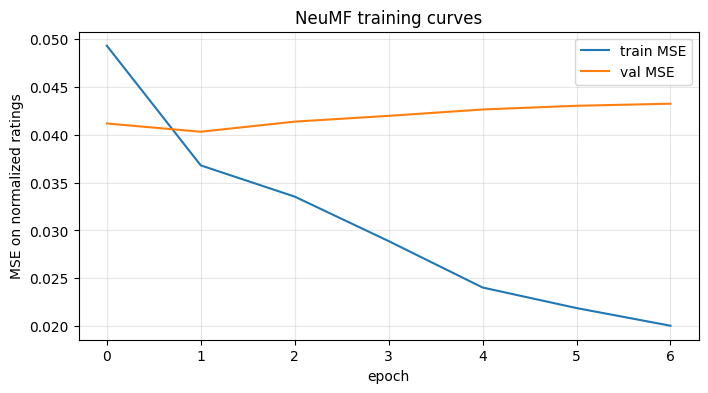

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train MSE')
plt.plot(history.history['val_loss'], label='val MSE')
plt.title('NeuMF training curves'); plt.xlabel('epoch'); plt.ylabel('MSE on normalized ratings'); plt.legend()
plt.grid(alpha=0.3); plt.show()

## Evaluation

Two prediction interfaces:
- `predict_pointwise(df)` → DataFrame with a `predicted_rating` column, used for RMSE/MAE.
- `predict_fn(user_id, movie_ids)` → np.ndarray of scores, used by the shared `evaluate_model` for HR@10 / NDCG@10 / Precision/Recall/F1@10.

In [10]:
def predict_pointwise(df):
    u = df['userId'].map(user2idx).to_numpy(dtype=np.int32)
    m = df['movieId'].map(movie2idx).to_numpy(dtype=np.int32)
    sig = model.predict([u, m], batch_size=1024, verbose=0).flatten()
    pred = sig * RATING_RANGE + RATING_MIN
    out = df[['userId', 'movieId', 'rating']].copy()
    out['predicted_rating'] = pred
    return out

def predict_fn(user_id, movie_ids):
    movie_ids = np.asarray(movie_ids)
    u_idx = user2idx.get(int(user_id))
    if u_idx is None:
        return np.zeros(len(movie_ids))
    encoded = np.array([movie2idx.get(int(m), -1) for m in movie_ids])
    valid = encoded >= 0
    scores = np.zeros(len(movie_ids), dtype=np.float32)
    if valid.any():
        u_arr = np.full(valid.sum(), u_idx, dtype=np.int32)
        m_arr = encoded[valid].astype(np.int32)
        scores[valid] = model.predict([u_arr, m_arr], batch_size=1024, verbose=0).flatten()
    return scores

In [11]:
candidates = build_candidate_lists(train, test, num_negatives=99, seed=SEED)
print(f'Built candidate lists for {len(candidates)} test interactions (1 + 99 negatives each).')

Built candidate lists for 610 test interactions (1 + 99 negatives each).


In [12]:
pointwise = predict_pointwise(test)
metrics = evaluate_model(predict_fn, test, candidates, pointwise_predictions=pointwise, k=10, threshold=3.5)

print('=== NeuMF — test set ===')
for key in ['rmse', 'mae', 'hr_at_k', 'ndcg_at_k', 'precision_at_k', 'recall_at_k', 'f1_at_k']:
    print(f'  {key:18s} = {metrics[key]:.4f}')

=== NeuMF — test set ===
  rmse               = 0.9871
  mae                = 0.7619
  hr_at_k            = 0.2852
  ndcg_at_k          = 0.1679
  precision_at_k     = 0.0239
  recall_at_k        = 0.2393
  f1_at_k            = 0.0435


## Save test-set predictions

The hybrid GBRT model needs every base model's predicted rating on every (user, item) pair it evaluates on. We save the test-set predictions here; the hybrid notebook handles out-of-fold cross-prediction on the training set.

In [13]:
out_path = PREDICTIONS_DIR / 'neural_cf.csv'
pointwise[['userId', 'movieId', 'predicted_rating']].to_csv(out_path, index=False)
print(f'Saved {len(pointwise)} predictions -> {out_path}')

Saved 610 predictions -> /content/gdrive/MyDrive/recsys_artifacts/predictions/neural_cf.csv
